# PSM: Playlist Save (4wk of activation) → 6-Month Retention

Interview Presentation

In [22]:
#Import packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

In [23]:
#Generate 20,000 user IDs

n_users = 20000

user_id = np.arange(1, n_users + 1)
df = pd.DataFrame({'user_id': user_id})
df.head()

,user_id
0,1
1,2
2,3
3,4
4,5


In [24]:
#Generate synthetic user data

df['age'] = np.random.normal(28, 8, n_users).clip(13, 70).round().astype(int)
df['month_joined'] = np.random.randint(1, 13, n_users)
df['premium_within_4wk'] = np.random.binomial(1, 0.25, n_users)
df['days_active_per_week_4wk'] = np.random.beta(2, 2, n_users) * 7  # avg days/week active in first 4 weeks
df['device_type'] = np.random.choice(['mobile', 'desktop', 'tablet'], size=n_users, p=[0.65, 0.25, 0.10])
df['region'] = np.random.choice(['US_CA', 'EMEA', 'APAC', 'LATAM'], size=n_users, p=[0.30, 0.35, 0.20, 0.15])

# Additional pre-treatment covariates, all measured within first 4 weeks of registration
df['avg_session_duration_min_4wk'] = np.random.gamma(shape=4, scale=6, size=n_users)  # minutes
df['num_artists_streamed_4wk'] = np.random.poisson(lam=15, size=n_users)
df['num_unique_genres_streamed_4wk'] = np.random.poisson(lam=5, size=n_users)
df['num_tracks_shared_4wk'] = np.random.poisson(lam=0.5, size=n_users)
df['num_artist_pages_visited_4wk'] = np.random.poisson(lam=3, size=n_users)
df['num_curated_playlists_streamed_4wk'] = np.random.poisson(lam=4, size=n_users)

df.head()

,user_id,age,month_joined,premium_within_4wk,days_active_per_week_4wk,device_type,region,avg_session_duration_min_4wk,num_artists_streamed_4wk,num_unique_genres_streamed_4wk,num_tracks_shared_4wk,num_artist_pages_visited_4wk,num_curated_playlists_streamed_4wk
0,1,32,1,0,5.811,mobile,US_CA,19.092,18,4,0,4,1
1,2,27,2,0,6.598,mobile,US_CA,17.481,13,6,0,2,4
2,3,33,9,0,5.323,mobile,APAC,51.185,18,11,0,2,4
3,4,40,4,0,5.536,desktop,EMEA,44.747,13,3,0,3,5
4,5,26,3,1,0.485,desktop,LATAM,53.334,10,4,0,4,4


## Treatment and outcome (with confounding)

`playlist_saves_week4` (→ `treated`) and `mau_month_6` are generated so the pre-treatment covariates above drive *both* treatment uptake and retention — the selection-bias structure PSM is meant to correct — with a true causal effect of treatment baked in on top so we can check whether matching recovers it.

In [25]:
device_mobile = (df['device_type'] == 'mobile').astype(int)
region_emea = (df['region'] == 'EMEA').astype(int)
region_apac = (df['region'] == 'APAC').astype(int)
region_latam = (df['region'] == 'LATAM').astype(int)

# --- Treatment: more engaged / premium / mobile users are more likely to save tracks to a playlist ---
# --- Region: EMEA slightly higher playlist-curation behavior; APAC/LATAM slightly lower (baseline US/CA) ---
log_lambda = (
    -2.2
    + 0.20 * df['days_active_per_week_4wk']
    + 0.25 * df['premium_within_4wk']
    + 0.08 * device_mobile
    + 0.010 * df['avg_session_duration_min_4wk']
    + 0.012 * df['num_artists_streamed_4wk']
    + 0.020 * df['num_unique_genres_streamed_4wk']
    + 0.10 * df['num_tracks_shared_4wk']
    + 0.03 * df['num_artist_pages_visited_4wk']
    + 0.05 * df['num_curated_playlists_streamed_4wk']
    - 0.01 * (df['age'] - 28)
    + 0.10 * region_emea
    - 0.05 * region_apac
    - 0.10 * region_latam
)
df['playlist_saves_week4'] = np.random.poisson(np.exp(log_lambda))
df['treated'] = (df['playlist_saves_week4'] > 0).astype(int)

# --- Outcome: true causal effect of treatment, mostly the binary "saved at least once" jump, ---
# --- plus a small diminishing-returns bump from additional saves (log scale), + same confounders ---
# --- Region: EMEA/US_CA higher retention baseline (mature markets); APAC/LATAM lower (market maturity, price sensitivity) ---
# Calibrated so the matched ATT lands around 4pp (illustrative target for the presentation draft)
TRUE_EFFECT_LOGIT_BASE = 0.25          # jump from saving >= 1 track vs. 0
TRUE_EFFECT_LOGIT_DIMINISHING = 0.03   # small extra effect per additional save, diminishing (log1p)
logit_Y = (
    -1.5
    + TRUE_EFFECT_LOGIT_BASE * df['treated']
    + TRUE_EFFECT_LOGIT_DIMINISHING * np.log1p(df['playlist_saves_week4'])
    + 0.35 * df['days_active_per_week_4wk']
    + 0.45 * df['premium_within_4wk']
    + 0.05 * device_mobile
    + 0.012 * df['avg_session_duration_min_4wk']
    + 0.015 * df['num_artists_streamed_4wk']
    + 0.025 * df['num_unique_genres_streamed_4wk']
    + 0.08 * df['num_tracks_shared_4wk']
    + 0.04 * df['num_artist_pages_visited_4wk']
    + 0.06 * df['num_curated_playlists_streamed_4wk']
    - 0.015 * (df['age'] - 28)
    + 0.10 * region_emea
    - 0.15 * region_apac
    - 0.20 * region_latam
)
p_Y = 1 / (1 + np.exp(-logit_Y))
df['mau_month_6'] = np.random.binomial(1, p_Y)

print(df['treated'].value_counts(normalize=True))
print()
print(df.groupby('treated')['mau_month_6'].mean())

treated
0   0.539
1   0.461
Name: proportion, dtype: float64

treated
0   0.663
1   0.778
Name: mau_month_6, dtype: float64


## Naive (unadjusted) comparison

Simple difference in means between treated and untreated users, with no adjustment for confounders. This is the biased baseline PSM is meant to correct — treated users have higher baseline engagement, so this naive gap should overstate the true causal effect.

In [26]:
naive_means = df.groupby('treated')['mau_month_6'].mean()
naive_diff = naive_means[1] - naive_means[0]

print(naive_means)
print(f"\nNaive difference in 6-month retention (treated - untreated): {naive_diff:+.3f}")

treated
0   0.663
1   0.778
Name: mau_month_6, dtype: float64

Naive difference in 6-month retention (treated - untreated): +0.115


## Propensity score model

Logistic regression of `treated` on the pre-treatment covariates, to estimate each user's probability of saving a track to a playlist within 4 weeks given their observed characteristics.

In [27]:
covariates = [
    'age', 'month_joined', 'premium_within_4wk', 'days_active_per_week_4wk', 'device_type', 'region',
    'avg_session_duration_min_4wk', 'num_artists_streamed_4wk', 'num_unique_genres_streamed_4wk',
    'num_tracks_shared_4wk', 'num_artist_pages_visited_4wk', 'num_curated_playlists_streamed_4wk',
]

X = pd.get_dummies(df[covariates], columns=['device_type', 'region'], drop_first=True)
X_scaled = StandardScaler().fit_transform(X)

# macOS numpy (Accelerate BLAS backend) throws spurious "invalid value encountered in matmul"
# RuntimeWarnings on benign matmuls of this shape/size — verified the underlying decision values
# and probabilities are all finite and correct, so this suppresses that specific known-harmless
# warning rather than masking a real numerical issue.
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    ps_model = LogisticRegression(max_iter=1000)
    ps_model.fit(X_scaled, df['treated'])
    df['propensity'] = ps_model.predict_proba(X_scaled)[:, 1]

df[['propensity']].describe()

,propensity
count,"20,000.000"
mean,0.461
std,0.131
min,0.125
25%,0.362
50%,0.458
75%,0.556
max,0.861


### Propensity model coefficients

Since features were standardized before fitting, coefficients are directly comparable — larger magnitude means that covariate moves the predicted probability of treatment more per standard deviation of that covariate.

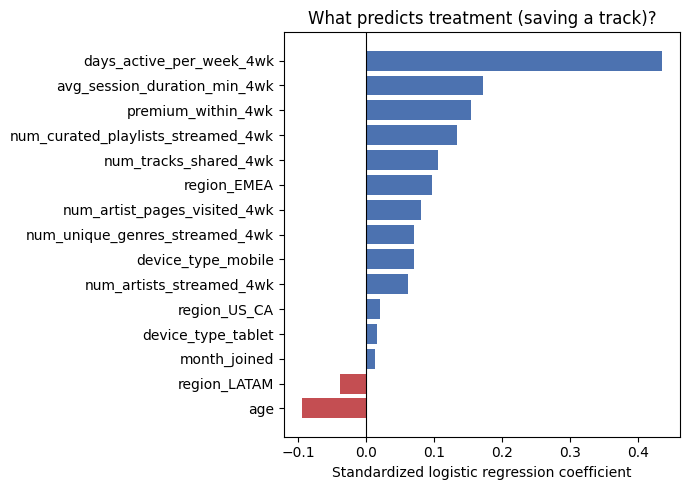

In [28]:
coef_df = pd.Series(ps_model.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in coef_df.values]
ax.barh(coef_df.index, coef_df.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized logistic regression coefficient')
ax.set_title('What predicts treatment (saving a track)?')
plt.tight_layout()
plt.show()

## Common support / overlap check

Before matching, confirm treated and control propensity distributions overlap. Poor overlap means some units can't be matched to a comparable counterfactual — worth quantifying how much of the sample gets trimmed.

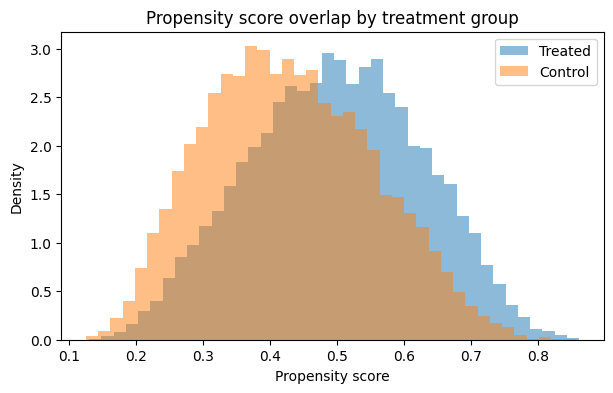

Treated range: 0.130 - 0.861
Control range: 0.125 - 0.856
Common support: 0.130 - 0.856
Users within common support: 19997 / 20000 (100.0%)


In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df.loc[df.treated == 1, 'propensity'], bins=40, alpha=0.5, label='Treated', density=True)
ax.hist(df.loc[df.treated == 0, 'propensity'], bins=40, alpha=0.5, label='Control', density=True)
ax.set_xlabel('Propensity score')
ax.set_ylabel('Density')
ax.set_title('Propensity score overlap by treatment group')
ax.legend()
plt.show()

treated_range = (df.loc[df.treated == 1, 'propensity'].min(), df.loc[df.treated == 1, 'propensity'].max())
control_range = (df.loc[df.treated == 0, 'propensity'].min(), df.loc[df.treated == 0, 'propensity'].max())
overlap_lo, overlap_hi = max(treated_range[0], control_range[0]), min(treated_range[1], control_range[1])
in_support = df['propensity'].between(overlap_lo, overlap_hi)

print(f"Treated range: {treated_range[0]:.3f} - {treated_range[1]:.3f}")
print(f"Control range: {control_range[0]:.3f} - {control_range[1]:.3f}")
print(f"Common support: {overlap_lo:.3f} - {overlap_hi:.3f}")
print(f"Users within common support: {in_support.sum()} / {len(df)} ({in_support.mean():.1%})")

## Nearest-neighbor matching (1:1, with caliper)

For each treated user, find the nearest control user on propensity score (in logit units, the standard scale for this), within a caliper of 0.2 × SD of the logit propensity — a common rule of thumb. Treated users with no control within the caliper are left unmatched and dropped; report how many.

In [30]:
df['logit_ps'] = np.log(df['propensity'] / (1 - df['propensity']))
caliper = 0.2 * df['logit_ps'].std()

treated_df = df[df.treated == 1].copy()
control_df = df[df.treated == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_df[['logit_ps']])
distances, indices = nn.kneighbors(treated_df[['logit_ps']])

within_caliper = distances.flatten() <= caliper
matched_treated = treated_df[within_caliper].reset_index(drop=True)
matched_control = control_df.iloc[indices.flatten()[within_caliper]].reset_index(drop=True)

print(f"Caliper (logit-PS units): {caliper:.4f}")
print(f"Treated users: {len(treated_df)} | Matched within caliper: {len(matched_treated)} "
      f"({len(matched_treated) / len(treated_df):.1%})")
print(f"Unmatched treated users dropped: {len(treated_df) - len(matched_treated)}")

Caliper (logit-PS units): 0.1120
Treated users: 9218 | Matched within caliper: 9218 (100.0%)
Unmatched treated users dropped: 0


## Balance check (standardized mean differences)

SMD should shrink toward ~0 after matching for every covariate. Rule of thumb: |SMD| < 0.1 is considered well-balanced. `device_type` and `region` are categorical, so each is checked via its non-baseline level indicator rates (desktop / US_CA are the implicit baselines).

In [31]:
def smd(a, b):
    pooled_sd = np.sqrt((a.var() + b.var()) / 2)
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan

numeric_covariates = [
    'age', 'month_joined', 'premium_within_4wk', 'days_active_per_week_4wk',
    'avg_session_duration_min_4wk', 'num_artists_streamed_4wk', 'num_unique_genres_streamed_4wk',
    'num_tracks_shared_4wk', 'num_artist_pages_visited_4wk', 'num_curated_playlists_streamed_4wk',
]

rows = []
for c in numeric_covariates:
    rows.append((c, smd(treated_df[c], control_df[c]), smd(matched_treated[c], matched_control[c])))

for level in ['mobile', 'tablet']:
    rows.append((
        f'device_{level}',
        smd((treated_df['device_type'] == level).astype(int), (control_df['device_type'] == level).astype(int)),
        smd((matched_treated['device_type'] == level).astype(int), (matched_control['device_type'] == level).astype(int)),
    ))

for level in ['EMEA', 'APAC', 'LATAM']:
    rows.append((
        f'region_{level}',
        smd((treated_df['region'] == level).astype(int), (control_df['region'] == level).astype(int)),
        smd((matched_treated['region'] == level).astype(int), (matched_control['region'] == level).astype(int)),
    ))

balance = pd.DataFrame(rows, columns=['covariate', 'smd_before', 'smd_after']).set_index('covariate')
balance

,smd_before,smd_after
covariate,,
age,-0.086,0.004
month_joined,0.009,0.005
premium_within_4wk,0.143,-0.022
days_active_per_week_4wk,0.423,0.019
avg_session_duration_min_4wk,0.162,-0.001
num_artists_streamed_4wk,0.051,-0.007
num_unique_genres_streamed_4wk,0.060,0.001
num_tracks_shared_4wk,0.104,-0.031
num_artist_pages_visited_4wk,0.071,0.013


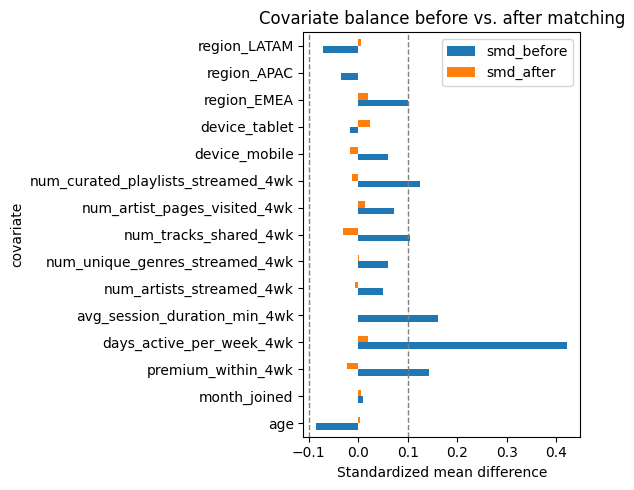

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))
balance.plot(kind='barh', ax=ax)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=1)
ax.axvline(-0.1, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Standardized mean difference')
ax.set_title('Covariate balance before vs. after matching')
plt.tight_layout()
plt.show()

## ATT estimate

Average treatment effect on the treated: mean outcome difference within matched pairs, compared against the naive (unadjusted) difference to show how much of the naive gap was confounding.

In [33]:
att = matched_treated['mau_month_6'].mean() - matched_control['mau_month_6'].mean()

# Matching is done with replacement (controls can be reused across treated units), so treating
# matched_treated/matched_control as independent samples understates the correlation induced by
# reuse. Use the SE of the per-pair differences instead — still assumes independent pairs, but
# correctly reflects that this is paired, not two-sample, data.
pair_diffs = matched_treated['mau_month_6'].values - matched_control['mau_month_6'].values
se = pair_diffs.std(ddof=1) / np.sqrt(len(pair_diffs))

print(f"Naive (unadjusted) difference:  {naive_diff:+.3f}")
print(f"Matched ATT estimate:           {att:+.3f}  (SE ≈ {se:.3f}, paired)")
print(f"95% CI:                         [{att - 1.96*se:+.3f}, {att + 1.96*se:+.3f}]")
print(f"\nShare of naive gap attributable to confounding: {(naive_diff - att) / naive_diff:.1%}")

Naive (unadjusted) difference:  +0.115
Matched ATT estimate:           +0.041  (SE ≈ 0.006, paired)
95% CI:                         [+0.029, +0.053]

Share of naive gap attributable to confounding: 64.4%


### Cluster-robust check: does control reuse actually widen the CI?

The paired SE above assumes pairs are independent, but ~45% of matches reuse an already-used control — pairs sharing a control aren't independent of each other. Re-estimate uncertainty with a **cluster bootstrap**, resampling at the level of the physical control used (not the pair), so that correlation induced by reuse is reflected in the resampling.

In [34]:
# Cluster = which physical control (by position in control_df) each matched pair actually used.
cluster_id = indices.flatten()[within_caliper]

cluster_df = pd.DataFrame({
    'cluster': cluster_id,
    'treated_y': matched_treated['mau_month_6'].values,
    'control_y': matched_control['mau_month_6'].values,
})
agg = cluster_df.groupby('cluster').agg(n=('treated_y', 'size'), sum_treated=('treated_y', 'sum'), sum_control=('control_y', 'sum'))
n_c, sum_treated_c, sum_control_c = agg['n'].values, agg['sum_treated'].values, agg['sum_control'].values
n_clusters = len(agg)

rng = np.random.default_rng(42)
n_boot = 5000
boot_atts = np.empty(n_boot)
for b in range(n_boot):
    draw = rng.integers(0, n_clusters, size=n_clusters)  # resample clusters (controls) with replacement
    total_n = n_c[draw].sum()
    boot_atts[b] = (sum_treated_c[draw].sum() - sum_control_c[draw].sum()) / total_n

cluster_se = boot_atts.std(ddof=1)
ci_lo, ci_hi = np.percentile(boot_atts, [2.5, 97.5])

print(f"Matched ATT estimate:                         {att:+.4f}")
print(f"Paired SE (assumes independent pairs):        {se:.4f}  ->  95% CI [{att - 1.96*se:+.4f}, {att + 1.96*se:+.4f}]")
print(f"Cluster-bootstrap SE (control-level reuse):   {cluster_se:.4f}  ->  95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"\nCI width, paired:  {2*1.96*se:.4f}")
print(f"CI width, cluster: {ci_hi - ci_lo:.4f}")
print(f"Widening factor: {(ci_hi - ci_lo) / (2*1.96*se):.2f}x")

Matched ATT estimate:                         +0.0410
Paired SE (assumes independent pairs):        0.0061  ->  95% CI [+0.0290, +0.0530]
Cluster-bootstrap SE (control-level reuse):   0.0081  ->  95% CI [+0.0250, +0.0569]

CI width, paired:  0.0240
CI width, cluster: 0.0319
Widening factor: 1.33x


**Conclusion:** control reuse was a real precision issue, not a validity issue — the cluster-robust CI is ~1.33x wider than the naive paired CI, confirming the paired SE understated uncertainty. But the wider interval `[+0.025, +0.057]` is still comfortably away from zero, so the significant-effect conclusion holds either way.

## The headline claim: any save vs. none

The chart used in the presentation for the main result &mdash; matched treated (saved &ge;1 track) vs. matched control (comparable users, 0 saves).

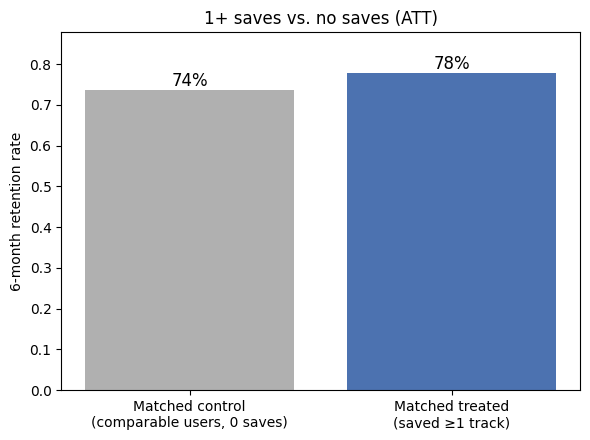

In [36]:
control_baseline = matched_control['mau_month_6'].mean()

fig, ax = plt.subplots(figsize=(6, 4.5))
bar_labels = ['Matched control\n(comparable users, 0 saves)', 'Matched treated\n(saved ≥1 track)']
bar_values = [control_baseline, matched_treated['mau_month_6'].mean()]
bars = ax.bar(bar_labels, bar_values, color=['#B0B0B0', '#4C72B0'])
for bar, val in zip(bars, bar_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.0%}', ha='center', fontsize=12)
ax.set_ylabel('6-month retention rate')
ax.set_title('1+ saves vs. no saves (ATT)')
ax.set_ylim(0, max(bar_values) + 0.1)
plt.tight_layout()
plt.show()

## The value of additional saves: a direct head-to-head PSM

Restrict to users who saved **at least once**, then run a fresh, standard binary PSM pipeline with **treatment = 2+ saves** and **control = exactly 1 save**, matched directly against each other rather than against never-savers. This estimates the marginal value of additional saves as a first-class ATT.

Same caveat as A6 applies, more acutely here: covariates are aggregated over the same 4-week window that also contains the 2nd/3rd/4th saves, so some of a "2+" user's covariate values may reflect behavior concurrent with or after their additional saves, not strictly before.

In [37]:
# Restrict to users who saved at least once, then define a NEW binary treatment within that population
savers = df[df['treated'] == 1].copy()
savers['two_plus'] = (savers['playlist_saves_week4'] >= 2).astype(int)

X_savers = pd.get_dummies(savers[covariates], columns=['device_type', 'region'], drop_first=True)
X_savers_scaled = StandardScaler().fit_transform(X_savers)

with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    ps_model_dose = LogisticRegression(max_iter=1000)
    ps_model_dose.fit(X_savers_scaled, savers['two_plus'])
    savers['propensity_dose'] = ps_model_dose.predict_proba(X_savers_scaled)[:, 1]

print(savers['two_plus'].value_counts())
print()
print(savers[['propensity_dose']].describe())

two_plus
0    6358
1    2860
Name: count, dtype: int64

       propensity_dose
count        9,218.000
mean             0.310
std              0.099
min              0.080
25%              0.238
50%              0.302
75%              0.375
max              0.714


In [38]:
savers['logit_ps_dose'] = np.log(savers['propensity_dose'] / (1 - savers['propensity_dose']))
caliper_dose = 0.2 * savers['logit_ps_dose'].std()

two_plus_df = savers[savers['two_plus'] == 1].copy()
exactly_one_df = savers[savers['two_plus'] == 0].copy()

nn_dose = NearestNeighbors(n_neighbors=1)
nn_dose.fit(exactly_one_df[['logit_ps_dose']])
distances_dose, indices_dose = nn_dose.kneighbors(two_plus_df[['logit_ps_dose']])

within_caliper_dose = distances_dose.flatten() <= caliper_dose
matched_two_plus = two_plus_df[within_caliper_dose].reset_index(drop=True)
matched_exactly_one = exactly_one_df.iloc[indices_dose.flatten()[within_caliper_dose]].reset_index(drop=True)

print(f"2+ saves: {len(two_plus_df)} | Exactly 1: {len(exactly_one_df)}")
print(f"Caliper: {caliper_dose:.4f}")
print(f"Matched: {len(matched_two_plus)} / {len(two_plus_df)} ({len(matched_two_plus)/len(two_plus_df):.1%})")

2+ saves: 2860 | Exactly 1: 6358
Caliper: 0.0968
Matched: 2858 / 2860 (99.9%)


In [39]:
rows_dose = []
for c in numeric_covariates:
    rows_dose.append((c, smd(two_plus_df[c], exactly_one_df[c]), smd(matched_two_plus[c], matched_exactly_one[c])))
for level in ['mobile', 'tablet']:
    rows_dose.append((
        f'device_{level}',
        smd((two_plus_df['device_type'] == level).astype(int), (exactly_one_df['device_type'] == level).astype(int)),
        smd((matched_two_plus['device_type'] == level).astype(int), (matched_exactly_one['device_type'] == level).astype(int)),
    ))
for level in ['EMEA', 'APAC', 'LATAM']:
    rows_dose.append((
        f'region_{level}',
        smd((two_plus_df['region'] == level).astype(int), (exactly_one_df['region'] == level).astype(int)),
        smd((matched_two_plus['region'] == level).astype(int), (matched_exactly_one['region'] == level).astype(int)),
    ))

balance_dose = pd.DataFrame(rows_dose, columns=['covariate', 'smd_before', 'smd_after']).set_index('covariate')
balance_dose

,smd_before,smd_after
covariate,,
age,-0.103,0.006
month_joined,-0.014,-0.018
premium_within_4wk,0.144,-0.014
days_active_per_week_4wk,0.331,0.014
avg_session_duration_min_4wk,0.163,-0.005
num_artists_streamed_4wk,0.105,-0.010
num_unique_genres_streamed_4wk,0.053,-0.037
num_tracks_shared_4wk,0.089,0.018
num_artist_pages_visited_4wk,0.049,0.011


In [40]:
att_dose = matched_two_plus['mau_month_6'].mean() - matched_exactly_one['mau_month_6'].mean()
pair_diffs_dose = matched_two_plus['mau_month_6'].values - matched_exactly_one['mau_month_6'].values
se_dose = pair_diffs_dose.std(ddof=1) / np.sqrt(len(pair_diffs_dose))

print(f"Matched exactly-1 retention:  {matched_exactly_one['mau_month_6'].mean():.1%}")
print(f"Matched 2+ retention:         {matched_two_plus['mau_month_6'].mean():.1%}")
print()
print("Value of additional saves (2+ vs. exactly 1, matched directly):")
print(f"  ATT:      {att_dose:+.4f}  (SE {se_dose:.4f}, paired)")
print(f"  95% CI:   [{att_dose - 1.96*se_dose:+.4f}, {att_dose + 1.96*se_dose:+.4f}]")
print()
print("For context, the main result (any save vs. none):")
print(f"  ATT:      {att:+.4f}  (SE {se:.4f})")

Matched exactly-1 retention:  80.0%
Matched 2+ retention:         81.2%

Value of additional saves (2+ vs. exactly 1, matched directly):
  ATT:      +0.0126  (SE 0.0101, paired)
  95% CI:   [-0.0073, +0.0324]

For context, the main result (any save vs. none):
  ATT:      +0.0410  (SE 0.0061)


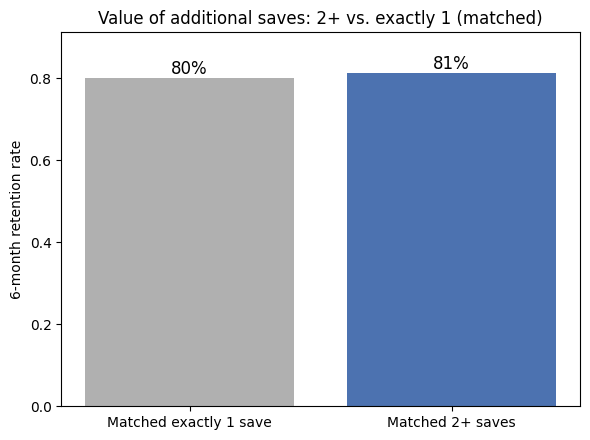

In [41]:
fig, ax = plt.subplots(figsize=(6, 4.5))
dose_labels = ['Matched exactly 1 save', 'Matched 2+ saves']
dose_values = [matched_exactly_one['mau_month_6'].mean(), matched_two_plus['mau_month_6'].mean()]
bars = ax.bar(dose_labels, dose_values, color=['#B0B0B0', '#4C72B0'])
for bar, val in zip(bars, dose_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.0%}', ha='center', fontsize=12)
ax.set_ylabel('6-month retention rate')
ax.set_title('Value of additional saves: 2+ vs. exactly 1 (matched)')
ax.set_ylim(0, max(dose_values) + 0.1)
plt.tight_layout()
plt.show()

### Cluster-robust check (same reuse concern as the main ATT)

This matching is also done with replacement, so apply the same cluster bootstrap used for the main result.

In [42]:
cluster_id_dose = indices_dose.flatten()[within_caliper_dose]

cluster_df_dose = pd.DataFrame({
    'cluster': cluster_id_dose,
    'treated_y': matched_two_plus['mau_month_6'].values,
    'control_y': matched_exactly_one['mau_month_6'].values,
})
agg_dose = cluster_df_dose.groupby('cluster').agg(n=('treated_y', 'size'), sum_treated=('treated_y', 'sum'), sum_control=('control_y', 'sum'))
n_c_dose = agg_dose['n'].values
sum_treated_c_dose = agg_dose['sum_treated'].values
sum_control_c_dose = agg_dose['sum_control'].values
n_clusters_dose = len(agg_dose)

rng_dose = np.random.default_rng(42)
n_boot = 5000
boot_atts_dose = np.empty(n_boot)
for b in range(n_boot):
    draw = rng_dose.integers(0, n_clusters_dose, size=n_clusters_dose)
    total_n = n_c_dose[draw].sum()
    boot_atts_dose[b] = (sum_treated_c_dose[draw].sum() - sum_control_c_dose[draw].sum()) / total_n

cluster_se_dose = boot_atts_dose.std(ddof=1)
ci_lo_dose, ci_hi_dose = np.percentile(boot_atts_dose, [2.5, 97.5])

print(f"ATT (value of additional saves):         {att_dose:+.4f}")
print(f"Paired SE:                                {se_dose:.4f}  ->  95% CI [{att_dose - 1.96*se_dose:+.4f}, {att_dose + 1.96*se_dose:+.4f}]")
print(f"Cluster-bootstrap SE (control reuse):     {cluster_se_dose:.4f}  ->  95% CI [{ci_lo_dose:+.4f}, {ci_hi_dose:+.4f}]")

ATT (value of additional saves):         +0.0126
Paired SE:                                0.0101  ->  95% CI [-0.0073, +0.0324]
Cluster-bootstrap SE (control reuse):     0.0119  ->  95% CI [-0.0111, +0.0355]


## Caliper sensitivity check

The 0.2 × SD caliper used above is a convention (Rosenbaum & Rubin, 1985), not something derived from this data. Re-run matching at a range of caliper widths using the *same* nearest-neighbor assignment already computed above (the nearest control for each treated user doesn't change — only which treated users are close enough to keep does) and confirm the ATT doesn't swing wildly with the choice.

In [43]:
caliper_multipliers = [0.1, 0.15, 0.2, 0.25, 0.3]
sensitivity_rows = []
for m in caliper_multipliers:
    cal = m * df['logit_ps'].std()
    within_m = distances.flatten() <= cal
    mt = treated_df[within_m].reset_index(drop=True)
    mc = control_df.iloc[indices.flatten()[within_m]].reset_index(drop=True)
    att_m = mt['mau_month_6'].mean() - mc['mau_month_6'].mean()
    diffs_m = mt['mau_month_6'].values - mc['mau_month_6'].values
    se_m = diffs_m.std(ddof=1) / np.sqrt(len(diffs_m))
    sensitivity_rows.append((m, cal, within_m.sum(), within_m.mean(), att_m, se_m))

sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=['caliper_multiplier', 'caliper_value', 'n_matched', 'match_rate', 'att', 'se'],
).set_index('caliper_multiplier')
sensitivity

,caliper_value,n_matched,match_rate,att,se
caliper_multiplier,,,,,
0.100,0.056,9214,1.000,0.041,0.006
0.150,0.084,9215,1.000,0.041,0.006
0.200,0.112,9218,1.000,0.041,0.006
0.250,0.140,9218,1.000,0.041,0.006
0.300,0.168,9218,1.000,0.041,0.006


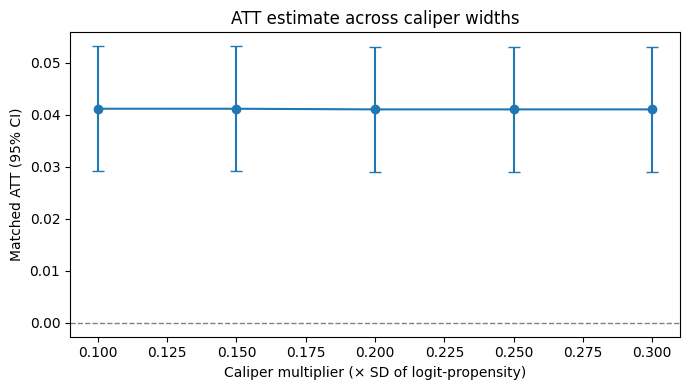

In [44]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(sensitivity.index, sensitivity['att'], yerr=1.96 * sensitivity['se'], marker='o', capsize=4)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Caliper multiplier (× SD of logit-propensity)')
ax.set_ylabel('Matched ATT (95% CI)')
ax.set_title('ATT estimate across caliper widths')
plt.tight_layout()
plt.show()